# Сергушов Павел ПМ22-4

### Лабораторная работа №1: **Классификация текстов на основе TF-IDF и Naive Bayes**
#### Практическая задача

Используя корпус данных новостей, выполните следующую последовательность шагов:

1. Загрузите и предобработайте данные: удалите стоп-слова, проведите лемматизацию/стемминг, преобразуйте все буквы в нижний регистр.
2. Создайте матрицу TF-IDF для вашего набора данных.
3. Разделите данные на тренировочный и тестовый наборы.
4. Постройте модель Naive Bayes на основе тренировочного набора.
5. Проверьте точность модели на тестовом наборе.
6. Проанализируйте результаты и сделайте выводы о качестве классификации.

#### Указания по выполнению

1. Используйте библиотеку `sklearn` для реализации TF-IDF и Naive Bayes.
2. Выберите подходящий корпус данных, например, новостные статьи или отзывы.
3. Проведите сравнительный анализ различных параметров модели (количество признаков, пороговые значения и т.д.) и выберите оптимальный вариант.
4. Подготовьте отчет, включающий код, графики и таблицы с результатами экспериментов.

#### Импорты

In [8]:
pip install pymorphy3

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter
import string
from razdel import tokenize
import zipfile
import pymorphy3
from nltk.corpus import stopwords
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreyserba/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Загрузка и предобработка датасета

In [11]:
data = pd.read_csv("lenta-ru-news.csv")

In [12]:
data.head()

,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,Первая мировая,1914/09/18


In [13]:
data.shape

(800975, 6)

In [14]:
data = data.drop(['url', 'title', 'tags', 'date'], axis = 1)

In [15]:
data.head()

,text,topic
0,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека
1,"Министерство народного просвещения, в виду про...",Библиотека
2,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека
3,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека
4,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека


In [16]:
data_without_nan = data[(~data['topic'].isna()) & (~data['text'].isna())]
data_without_nan

,text,topic
0,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека
1,"Министерство народного просвещения, в виду про...",Библиотека
2,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека
3,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека
4,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека
...,...,...
739171,Протесты движения «желтых жилетов» в Париже сн...,Мир
739172,Истребитель Су-27 разбился в Житомирской облас...,Бывший СССР
739173,В Московском районе Санкт-Петербурга на продаж...,Дом
739174,Швейцарский горнолыжник Марк Гизин неудачно пр...,Спорт


In [17]:
topic_counts = data_without_nan['topic'].value_counts()
topic_counts

topic
Россия               160442
Мир                  136620
Экономика             79528
Спорт                 64413
Культура              53796
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44663
Из жизни              27605
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64

In [18]:
topics = ['Дом', 'Культура', 'Спорт', 'Экономика']

In [19]:
filtered_data = data_without_nan[data_without_nan['topic'].isin(topics)]
filtered_data

,text,topic
630,С 1 января 2000 года все телеканалы будут опла...,Экономика
635,Германский автопромышленный концерн Volkswagen...,Экономика
636,"Нераспределенная прибыль ОАО ""Тюменнефтегаз"", ...",Экономика
660,Две крупнейших телекоммуникационных компании С...,Экономика
661,"ОАО ""ГАЗ"" и Нижегородский банк Сбербанка Росси...",Экономика
...,...,...
739159,Американский боец смешанного стиля (MMA) Фрэн...,Спорт
739167,Главный тренер «Манчестер Юнайтед» Жозе Моурин...,Спорт
739168,"Президент России Владимир Путин, выступая на з...",Культура
739173,В Московском районе Санкт-Петербурга на продаж...,Дом


In [20]:
samples_count = 5000
cropped_data = filtered_data.groupby("topic", group_keys=False).apply(lambda x: x.sample(samples_count))

In [21]:
cropped_data

,text,topic
265073,Корпорация Microsoft отложила планы по строите...,Дом
567764,В рамках ведущей премии в области жилой городс...,Дом
612711,За два года количество высоток в столице увели...,Дом
374501,"Девелоперская компания ""Дон-Строй Инвест"" до 2...",Дом
521280,"Правительство РФ подготовило законопроект, сог...",Дом
...,...,...
714078,Бизнесмен Олег Дерипаска вышел из совета дирек...,Экономика
301725,Правительство Монголии 6 октября подписало с к...,Экономика
260335,"Официальный курс европейской валюты, установле...",Экономика
709140,Заявление президента США Дональда Трампа о нам...,Экономика


In [22]:
morph = pymorphy3.MorphAnalyzer()
russian_stopwords = set(stopwords.words("russian"))
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r'\d+', '', text)
    tokens = [token.text for token in tokenize(text)]
    tokens = [morph.parse(word)[0].normal_form for word in tokens if word not in russian_stopwords]
    return " ".join(tokens)

In [23]:
# Измеряем время предобработки текста
print('Начало предобработки всех текстов')
start_time = time.time()
cropped_data["clean_text"] = cropped_data["text"].apply(preprocess_text)
end_time = time.time()
print(f"Время предобработки всех текстов: {end_time - start_time:.2f} секунд")

Начало предобработки всех текстов
Время предобработки всех текстов: 827.80 секунд


In [24]:
print(f"Форма данных: {cropped_data.shape}")
print(f"Первые 5 строк:")
cropped_data.head()

Форма данных: (20000, 3)
Первые 5 строк:


,text,topic,clean_text
265073,Корпорация Microsoft отложила планы по строите...,Дом,корпорация microsoft отложить план строительст...
567764,В рамках ведущей премии в области жилой городс...,Дом,рамка ведущий премия область жилой городской н...
612711,За два года количество высоток в столице увели...,Дом,год количество высотка столица увеличиться тре...
374501,"Девелоперская компания ""Дон-Строй Инвест"" до 2...",Дом,девелоперский компания дон строй инвест год пл...
521280,"Правительство РФ подготовило законопроект, сог...",Дом,правительство рф подготовить законопроект согл...


In [25]:
cropped_data.to_csv('cropped_data_new.csv', index=False, encoding="utf-8-sig", sep = '\t')

In [26]:
cropped_data = pd.read_csv('cropped_data_new.csv', sep = '\t')
cropped_data.head()

,text,topic,clean_text
0,Корпорация Microsoft отложила планы по строите...,Дом,корпорация microsoft отложить план строительст...
1,В рамках ведущей премии в области жилой городс...,Дом,рамка ведущий премия область жилой городской н...
2,За два года количество высоток в столице увели...,Дом,год количество высотка столица увеличиться тре...
3,"Девелоперская компания ""Дон-Строй Инвест"" до 2...",Дом,девелоперский компания дон строй инвест год пл...
4,"Правительство РФ подготовило законопроект, сог...",Дом,правительство рф подготовить законопроект согл...


In [27]:
print("\nПропущенные значения:")
print(cropped_data.isnull().sum())


Пропущенные значения:
text          0
topic         0
clean_text    0
dtype: int64


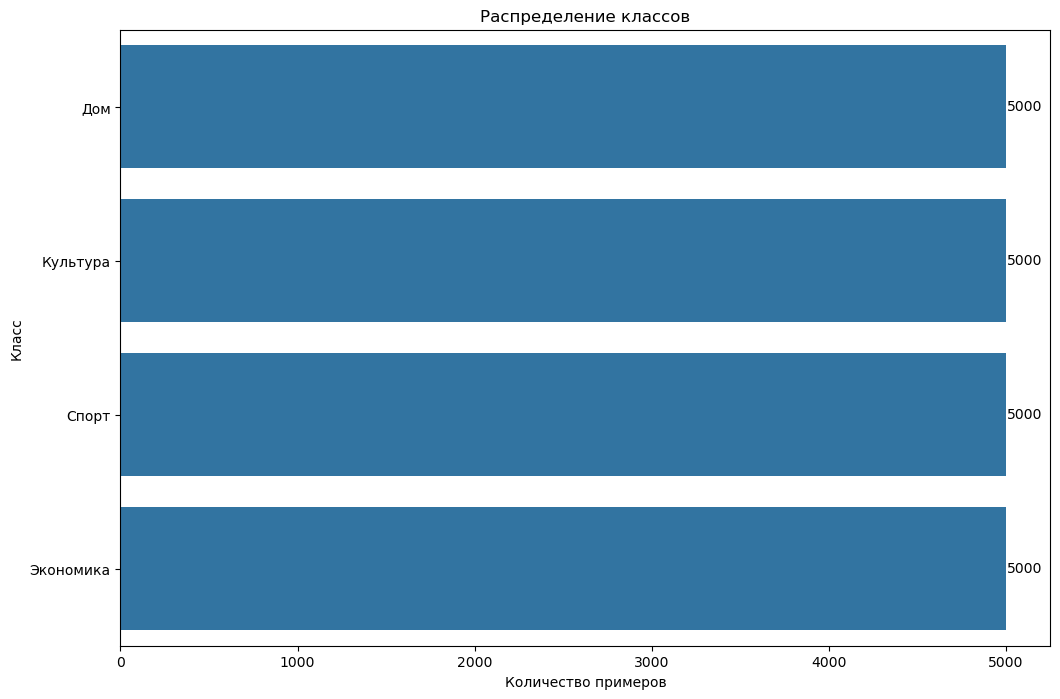

In [28]:
plt.figure(figsize=(12, 8))
sns.countplot(y=cropped_data['topic'], order=cropped_data['topic'].value_counts().index)
plt.title('Распределение классов')
plt.xlabel('Количество примеров')
plt.ylabel('Класс')

for i in range(len(cropped_data['topic'].value_counts())):
    count = cropped_data['topic'].value_counts().values[i]
    plt.text(count + 5, i, str(count), va='center')

plt.show()

In [29]:
print("\nПримеры текстов до и после обработки:")
for i in range(min(3, len(cropped_data))):
    print(f"Оригинал: {cropped_data['text'].iloc[i][:100]}...")
    print(f"Обработанный: {cropped_data['clean_text'].iloc[i][:100]}...")
    print()


Примеры текстов до и после обработки:
Оригинал: Корпорация Microsoft отложила планы по строительству новых корпусов на территории своего кампуса в г...
Обработанный: корпорация microsoft отложить план строительство новый корпус территория свой кампус город редмонд ш...

Оригинал: В рамках ведущей премии в области жилой городской недвижимости Urban Awards 2015 впервые будут особо...
Обработанный: рамка ведущий премия область жилой городской недвижимость urban awards впервые быть особо представит...

Оригинал: За два года количество высоток в столице увеличилось на треть, говорится в исследовании компании Est...
Обработанный: год количество высотка столица увеличиться треть говориться исследование компания est a tet август г...



#### Деление на тест и трейн

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    cropped_data['clean_text'], 
    cropped_data['topic'], 
    test_size=0.2
)
print(f"Размер тренировочного набора: {len(X_train)}")
print(f"Размер тестового набора: {len(X_test)}")

Размер тренировочного набора: 16000
Размер тестового набора: 4000


In [31]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Размерность матрицы TF-IDF для обучающих данных: {X_train_tfidf.shape}")
print(f"Размерность матрицы TF-IDF для тестовых данных: {X_test_tfidf.shape}")

Размерность матрицы TF-IDF для обучающих данных: (16000, 71682)
Размерность матрицы TF-IDF для тестовых данных: (4000, 71682)


In [32]:
def plot_confusion_matrix(conf_matrix):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(set(y_test)), 
            yticklabels=sorted(set(y_test)))
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.title('Матрица ошибок')
    plt.tight_layout()
    plt.show()

#### Построение базовой модели

Точность базовой модели: 0.9605

Отчет по классификации:
              precision    recall  f1-score   support

         Дом       0.93      0.94      0.93       985
    Культура       0.97      0.96      0.96      1016
       Спорт       1.00      0.99      0.99      1002
   Экономика       0.95      0.96      0.95       997

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



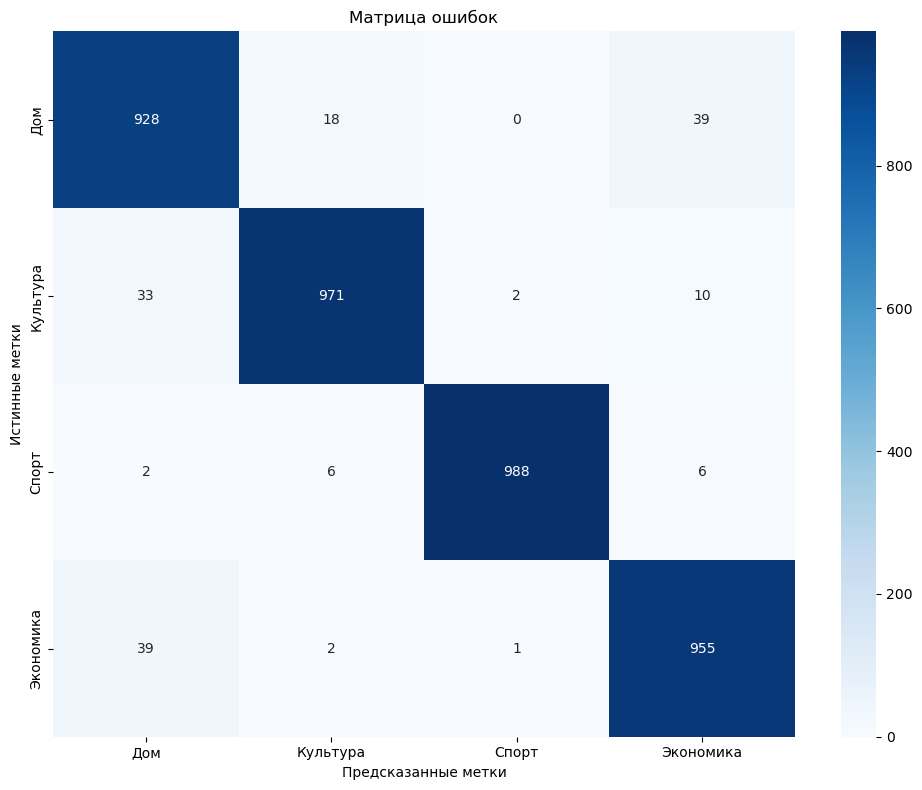

In [33]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred = nb.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Точность базовой модели: {accuracy:.4f}")
print("\nОтчет по классификации:")
print(report)
plot_confusion_matrix(conf_matrix)

Базовая модель с параметрами по умолчанию показала следующие результаты:
- Accuracy: 0.96
- Средняя Precision: 0.96
- Средний Recall: 0.96
- Средний F1-score: 0.96,    
что является отличными результатами

Лучше всего модель классифицирует тексты категории "Спорт" (F1-score 0.99) - это объясняется специфичной спортивной терминологией, которая редко встречается в других категориях

Проведу сравнение нескольких моделей с разными гиперпараметрами

In [34]:
configurations = [
    {
        'name': 'Базовая модель',
        'tfidf_params': {'max_features': None},
        'model_params': {'alpha': 1.0}
    },
    {
        'name': 'Ограниченные признаки TFIDF',
        'tfidf_params': {'max_features': 5000},
        'model_params': {'alpha': 1.0}
    },
    {
        'name': 'Биграммы',
        'tfidf_params': {'max_features': None, 'ngram_range': (1, 2)},
        'model_params': {'alpha': 1.0}
    },
    {
        'name': 'Сильное сглаживание',
        'tfidf_params': {'max_features': None},
        'model_params': {'alpha': 5}
    },
    {
        'name': 'Слабое сглаживание',
        'tfidf_params': {'max_features': None},
        'model_params': {'alpha': 0.1}
    },
    {
        'name': 'Слабое сглаживание с биграммами',
        'tfidf_params': {'max_features': None, 'ngram_range': (1, 2)},
        'model_params': {'alpha': 0.1}
    },
]

In [35]:
results = {}
trained_models = {}

for config in configurations:
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(**config['tfidf_params'])),
        ('classifier', MultinomialNB(**config['model_params']))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')
    
    pipeline.fit(X_train, y_train)
    trained_models[config['name']] = pipeline
    
    results[config['name']] = {
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std(),
        'model': pipeline
    }
    
    print(f"Модель: {config['name']}")
    print(f"Средняя точность: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"Параметры TF-IDF: {config['tfidf_params']}")
    print(f"Параметры модели: {config['model_params']}")
    print("-" * 50)

Модель: Базовая модель
Средняя точность: 0.9560 ± 0.0036
Параметры TF-IDF: {'max_features': None}
Параметры модели: {'alpha': 1.0}
--------------------------------------------------
Модель: Ограниченные признаки TFIDF
Средняя точность: 0.9538 ± 0.0017
Параметры TF-IDF: {'max_features': 5000}
Параметры модели: {'alpha': 1.0}
--------------------------------------------------
Модель: Биграммы
Средняя точность: 0.9583 ± 0.0025
Параметры TF-IDF: {'max_features': None, 'ngram_range': (1, 2)}
Параметры модели: {'alpha': 1.0}
--------------------------------------------------
Модель: Сильное сглаживание
Средняя точность: 0.9509 ± 0.0025
Параметры TF-IDF: {'max_features': None}
Параметры модели: {'alpha': 5}
--------------------------------------------------
Модель: Слабое сглаживание
Средняя точность: 0.9570 ± 0.0036
Параметры TF-IDF: {'max_features': None}
Параметры модели: {'alpha': 0.1}
--------------------------------------------------
Модель: Слабое сглаживание с биграммами
Средняя точно

In [36]:
results_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'Средняя точность': [results[model]['mean_accuracy'] for model in results],
    'Стандартное отклонение': [results[model]['std_accuracy'] for model in results]
})

results_df = results_df.sort_values('Средняя точность', ascending=False).reset_index(drop=True)
results_df

,Модель,Средняя точность,Стандартное отклонение
0,Слабое сглаживание с биграммами,0.963005,0.002655
1,Биграммы,0.958271,0.002485
2,Слабое сглаживание,0.957043,0.003644
3,Базовая модель,0.955969,0.003598
4,Ограниченные признаки TFIDF,0.953777,0.001657
5,Сильное сглаживание,0.950924,0.002461


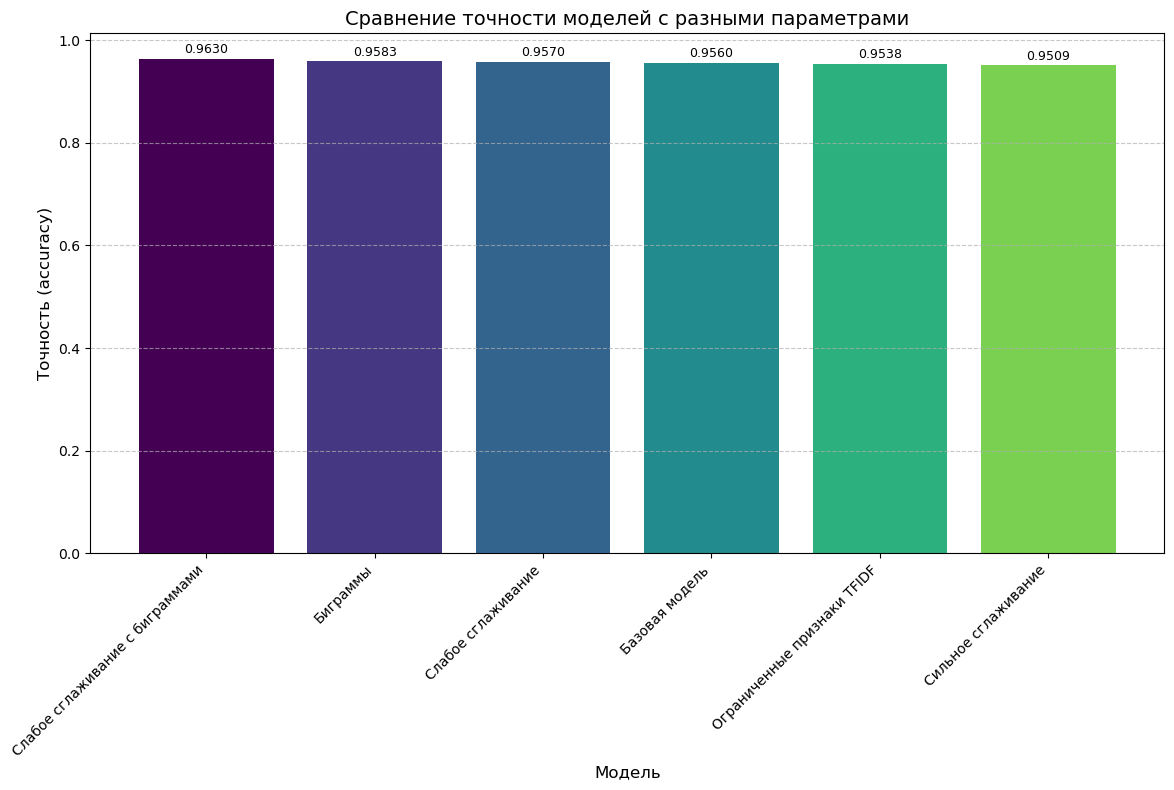

In [37]:
plt.figure(figsize=(12, 8))

models = results_df['Модель']
accuracies = results_df['Средняя точность']

colors = plt.cm.viridis(np.linspace(0, 0.8, len(models)))

bars = plt.bar(models, accuracies,  capsize=10, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.title('Сравнение точности моделей с разными параметрами', fontsize=14)
plt.ylabel('Точность (accuracy)', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(top=max(accuracies) + 0.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Сравнение всех протестированных моделей


Лучшей оказалась модель со слабым сглаживанием (уменьшенный параметр alpha) и биграммами

Уменьшение параметра сглаживания (alpha) с 1.0 до 0.1 улучшило точность модели. Это говорит о том, что данные не содержат много шума, который нужно было бы сгладить

Также добавление биграмм в качестве признаков также немного увеличило точность модели. Следовательно, некоторые пары слов имеют более высокое влияние, чем отдельные слова.

Проверим метрики лучшей модели на тесте

In [38]:
best_model = results['Слабое сглаживание с биграммами']['model']
best_model

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier', MultinomialNB(alpha=0.1))])

F1 score на тесте: 0.9677
Classification Report:
              precision    recall  f1-score   support

         Дом       0.94      0.96      0.95       985
    Культура       0.97      0.97      0.97      1016
       Спорт       1.00      0.99      0.99      1002
   Экономика       0.96      0.96      0.96       997

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



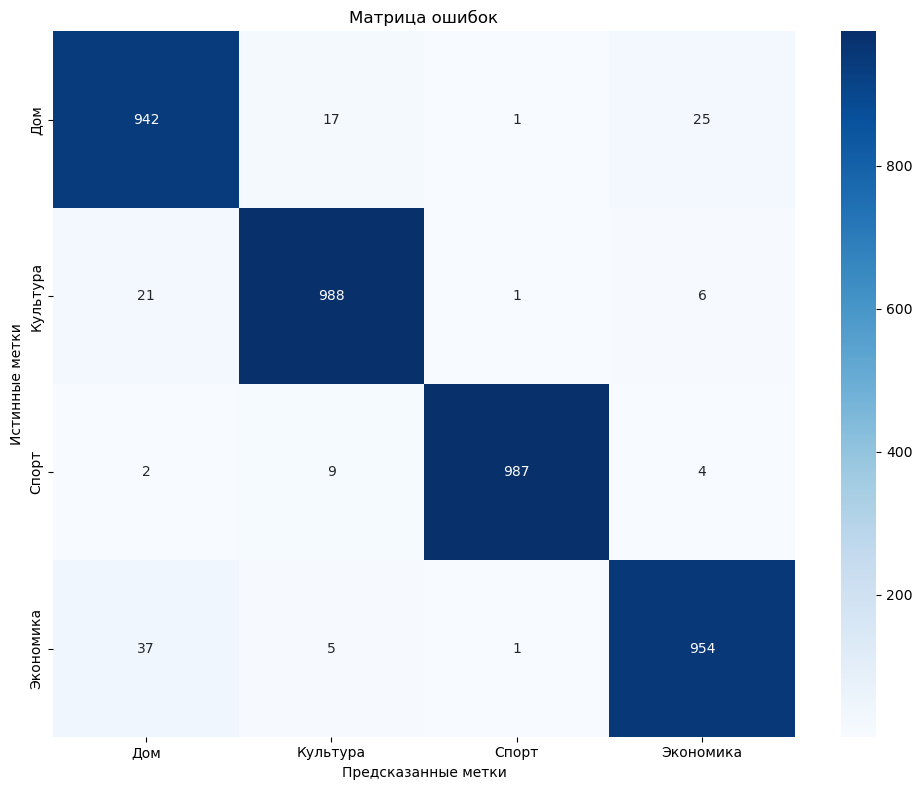

In [39]:
y_pred = best_model.predict(X_test)

accuracy = f1_score(y_test, y_pred, average = 'macro')
print(f'F1 score на тесте: {round(accuracy, 4)}')

print("Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_matrix)

У лучшей модели метрики улучшились на +-1% в сравнении с базовой моделью с параметрами по умолчанию

Визуализирую важность признаков для каждой темы

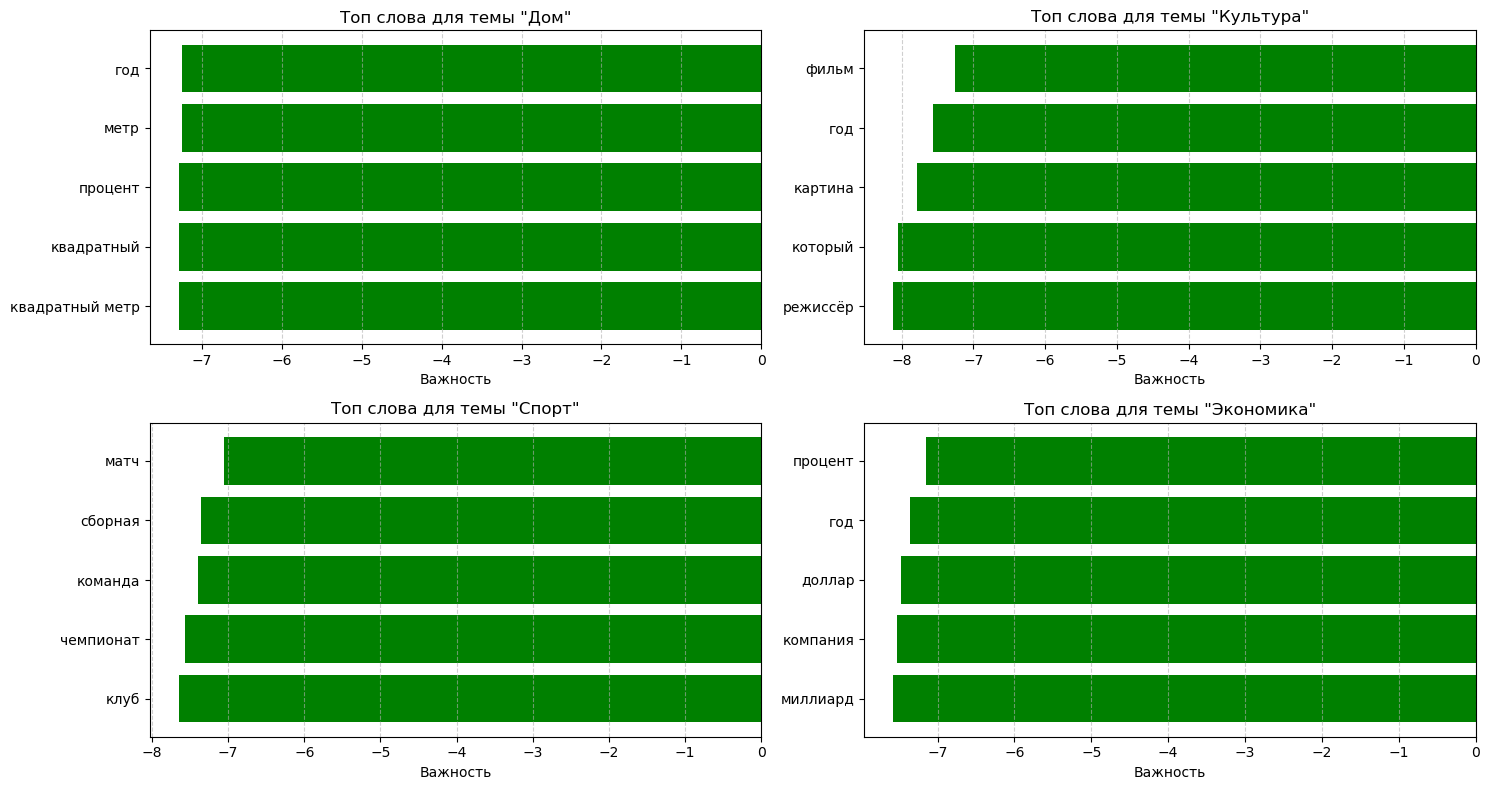

In [40]:
feature_names = best_model.named_steps['tfidf'].get_feature_names_out()
class_names = best_model.classes_

top_n = 5

n_classes = len(class_names)
n_cols = 2 
n_rows = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  #
classifier = best_model.named_steps['classifier']
X_tfidf = best_model.named_steps['tfidf'].transform(X_train)

for i, class_name in enumerate(class_names):
    if i < len(axes):
        ax = axes[i]
        
        top_indices = np.argsort(classifier.feature_log_prob_[i])[-top_n:]
        
        top_words = [feature_names[idx] for idx in top_indices]
        top_values = [classifier.feature_log_prob_[i][idx] for idx in top_indices]
        
        sorted_indices = np.argsort(top_values)
        top_words = [top_words[j] for j in sorted_indices]
        top_values = [top_values[j] for j in sorted_indices]
        
        ax.barh(top_words, top_values, color='green')
        
        ax.set_title(f'Топ слова для темы "{class_name}"')
        ax.set_xlabel('Важность')
        ax.grid(axis='x', linestyle='--', alpha=0.6)

for i in range(n_classes, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

В целом, наивный байес показал достаточно хорошие результаты для классификации текстов новостей, достигнув 95% точности

Использование биграмм улучшило результаты, показывая важность контекста слов в новостных текстах.

Как мне кажется, проблемой может являеться то, что во многих категориях происходит пересечение слов, и т.к. мы используем TF-IDF, то можем получить несильно хорошее качество у моделей для отдельных тем